# MoA — TabPFN (Early_Toxicity_Screening_ML_Comparison)

- 사용한 모델: 
    > **Logistic Regression / Random Forest / LightGBM / XGBoost**

기존 다중 레이블(`tabpfn_basic_pca500_holdout.ipynb`) MoA 예측 파이프라인을 **세포 생존율(`c-`)기반 독성 이진 분류 모델**로 수정.

목적:
- 화학구조(SMILES)와 약물(drug_id) 매핑이 불가하다는 한계를 극복하기 위함
  -> 유전자 발현량(`g-`) 데이터의 변화 시그니처만으로 화합물의 잠재적인 세포 독성을 조기 예측

전처리 흐름: 
1. **정답지 생성** : `c-` 컬럼의 평균 세포 생존율을 계산하여, 특정 임계값(ex. -2.0)이하로 떨어지는 것을 고독성 / 아닌 것을 정상으로 라벨링
2. **Feature / Target 분리**
    : **`Target`** - 정답지 생성에 사용된 `c-` 컬럼들은 모델 입력(Feature)에서 완전히 제외(Drop)
    : **`Feature`** - 오직 `g-` 컬럼과 실험 조건(`cp_time`, `cp_dose`)만 남김.
3. **스케일링 &인코딩**
    - `cp_time`,`cp_dose` 정수 인코딩 / exposure_score 적용
    - `g-` : QuantileTransformer (train_split에 fit → val transform)
     >`QuantileTransformer` : 1등부터 순서대로 줄을 세우고, 0~1안의 수로 백분위로 표현
     >Train에만 fit하는 이유: TEST의 힌트를 얻을 수 있기에, 데이터 누수가 발생할 수 있음. 이에, Train에만 fit수행 (이후, transform하여 0~1사이 값으로 바꿈 -> Val transform)
     > Val transform: Train 데이터로 제작한 기준표를 기대로 가져와서 Test도 변경
4. **차원 축소**
    - PCA(n=500) — train_split 에 fit → 양쪽 transform
    - **`상호작용항 생성`** : 주성분 * exposure_score
5. **모델 학습**
    - 206개 target 각각에 4가지 ML 독립 학습
    > **Logistic Regression / Random Forest / LightGBM / XGBoost**

## **0. 라이브러리 로드**

In [35]:
#!pip install lightgbm xgboost

In [36]:
import os
import time
import random
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss

# ML 벤치마킹 모델 라이브러리
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

## **1. 경로 / 설정**

In [37]:
DATA_DIR   = '../data/'
OUTPUT_DIR = 'moa_outputs_Cytotoxicity_Prediction'
SUB_DIR    = 'Early_Toxicity_Screening_ML_Comparison'
DEVICE     = 'cpu'
SEED       = 42
N_SPLITS   = 5
VAL_FOLD   = 0

PCA_N_COMPONENTS = 500   # PCA로 차원 축소할 때 보존할 최대 주성분 수. (실제 데이터에 따라 다르게 설정가능)
MAX_TARGETS      = None  # 디버그용. 전체는 None.

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/{SUB_DIR}', exist_ok=True)

## **2. 데이터 로드 (train 만)**

In [38]:
random.seed(SEED); np.random.seed(SEED)

# 데이터 로드
drug_df = pd.read_csv(f'{DATA_DIR}train_drug.csv')
train_df = pd.read_csv(f'{DATA_DIR}train_features.csv')
test_df = pd.read_csv(f'{DATA_DIR}test_features.csv')

# 대조군(약물 넣지 않은 Sample) 제거
 # 약물의 독성 평가이므로, 대조군은 학습에서 제거.
train_df = train_df[train_df['cp_type'] != 'ctl_vehicle'].reset_index(drop=True)
test_df = test_df[test_df['cp_type'] != 'ctl_vehicle'].reset_index(drop=True)

# Drug_id 병합
train_df = pd.merge(train_df, drug_df[['drug_id', 'sig_id']], on='sig_id', how='left')
test_df = pd.merge(test_df, drug_df[['drug_id', 'sig_id']], on='sig_id', how='left')

print("Train_df과 Test_df에 drug_id 병합 완료")
print(f"train_df (Original Features) : {train_df.shape}")
print(f"test_df  (Original Features) : {test_df.shape}")

Train_df과 Test_df에 drug_id 병합 완료
train_df (Original Features) : (21948, 877)
test_df  (Original Features) : (3624, 877)


___
# **3. 전처리 시작**

## **1] 정답지 생성** 
- `c-` 컬럼의 평균 세포 생존율을 계산하여, 특정 임계값(ex. -2.0)이하로 떨어지는 것을 `고독성`, 아닌 것을 `정상`으로 라벨링

In [39]:
# 'c-' 로 시작하는 c- 컬럼 추출
c_cols = [col for col in train_df.columns if col.startswith('c-')]
print(f" -> 성공적으로 찾아낸 c- 컬럼 개수: {len(c_cols)}개")

# c-mean(세포 생존율의 평균)이 -2.0 이하인 경우를 독성으로 간주하여 라벨링 (1: 독성, 0: 정상)
train_df['c_mean'] = train_df[c_cols].mean(axis=1)
train_df['toxicity'] = (train_df['c_mean'] <= -2.0).astype(int)

toxicity_count = train_df['toxicity'].sum()
total_count = len(train_df)
toxic_ration = (toxicity_count / total_count) * 100

print("\n=== 독성 데이터(Label=1) 정답지 생성 ===")
print(f" -> 생성된 독성 데이터 수: {train_df['toxicity'].sum()}개 (전체의 {toxic_ration:.1f}%)")

 -> 성공적으로 찾아낸 c- 컬럼 개수: 100개

=== 독성 데이터(Label=1) 정답지 생성 ===
 -> 생성된 독성 데이터 수: 1756개 (전체의 8.0%)


In [40]:
print("\n=== 기준별 독성 물질(Label=1) 개수 비교 ===")
threshold_names = ["Z-score -1.0", "Z-score -1.5", "Z-score -2.0", "하위 5%", "하위 10%"]

# 실제 계산에 사용할 기준점들
thresholds_to_test = [
    -1.0, 
    -1.5, 
    -2.0, 
    train_df['c_mean'].quantile(0.05), 
    train_df['c_mean'].quantile(0.10)
]
for name, th in zip(threshold_names, thresholds_to_test):
    # 해당 기준을 적용했을 때 독성 물질의 개수
    toxic_count = (train_df['c_mean'] <= th).sum()
    total_count = len(train_df)
    ratio = (toxic_count / total_count) * 100
    print(f"{name} (기준점: {th:6.3f}) -> 독성물질: {toxic_count:4d}개 ({ratio:.1f}%)")


=== 기준별 독성 물질(Label=1) 개수 비교 ===
Z-score -1.0 (기준점: -1.000) -> 독성물질: 2415개 (11.0%)
Z-score -1.5 (기준점: -1.500) -> 독성물질: 1990개 (9.1%)
Z-score -2.0 (기준점: -2.000) -> 독성물질: 1756개 (8.0%)
하위 5% (기준점: -4.477) -> 독성물질: 1098개 (5.0%)
하위 10% (기준점: -1.213) -> 독성물질: 2195개 (10.0%)


___
## **2] Feature / Target 분리 (데이터 누수 방지)**
- 데이터 누수: 동일 실험의 약물의 데이터를 무작위 분할할 경우! 특정 패턴만 보고, 독성이 있다고 판단할 수 있음
 -> 이에, drug_id를 가져와 같은 drug_id만 따로 추출해 확인하고자 함.

In [41]:
# 모델이 학습할 문제(X)와 정답(y) 나누기
cols_to_drop = c_cols + ['sig_id', 'c_mean', 'toxicity', 'cp_type', 'drug_id']

X = train_df.drop(columns=cols_to_drop, errors='ignore')
y = train_df['toxicity']                

# 데이터 누수 방지 -> drug_id 따로 추출
groups = train_df['drug_id']

# test도 동일하게 제작
X_test = test_df.drop(columns=c_cols + ['sig_id', 'cp_type'], errors='ignore')

print("Feature, Target 분리 완료")
print(f"\n문제지 크기: {X.shape}")
print(f"정답지 크기: {y.shape}")
print(f"테스트 문제지 크기: {X_test.shape}")

Feature, Target 분리 완료

문제지 크기: (21948, 774)
정답지 크기: (21948,)
테스트 문제지 크기: (3624, 775)


___
## **3] 스케일링 및 인코딩**
- `cp_time`,`cp_dose` 정수 인코딩
- `g-` : QuantileTransformer (train_split에 fit → val transform)

___
### **Train과 Test 데이터 나누기**
___

In [42]:
# Train, Test 데이터 생성
 # stratify=y 를 통해 '독성 물질(Label=1)'이 양쪽 그룹에 골고루 분포하도록 나눔
from sklearn.model_selection import train_test_split

# 같은 drug_id 가진 데이터 함께 묶어 분할 수행
drug_s = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(drug_s.split(X, y, groups=groups))

print("Train, Test 데이터 나누기")
X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
y_train, y_val = y.iloc[train_idx].values, y.iloc[val_idx].values

print("Train, Test 데이터 나누기 완료")
print(f"\n학습 데이터 크기: {X_train.shape}, 검증용 데이터 크기: {X_val.shape}")

Train, Test 데이터 나누기


Train, Test 데이터 나누기 완료

학습 데이터 크기: (17638, 774), 검증용 데이터 크기: (4310, 774)


___
### **스케일링 및 인코딩**

- 유전자와 실험 조건 데이터는 성격이 다르므로, 스케일링 및 PCA 차원 축소단계에서 다르게 다룸
___

In [43]:
# 범주형 데이터(cp_time, cp_dose) 정수 인코딩
# 시간(24h, 48h, 72h) -> 0, 1, 2
# 용량(D1, D2) -> 0, 1

# 노출 지수에 따라 최소 1~최대 6까지 생성 
for df in [X_train, X_val, X_test]:
    # 기존 범주형 인코딩 (0, 1, 2)
    df['cp_time_enc'] = df['cp_time'].map({24: 0, 48: 1, 72: 2})
    df['cp_dose_enc'] = df['cp_dose'].map({'D1': 0, 'D2': 1})
    
    # 노출 지수(exposure_score) 계산을 위한 가중치 (1, 2, 3 스케일)
    time_weight = df['cp_time'].map({24: 1, 48: 2, 72: 3})
    dose_weight = df['cp_dose'].map({'D1': 1, 'D2': 2})
    
    # 노출 지수 생성 (최소 1 ~ 최대 6)
    df['exposure_score'] = time_weight * dose_weight

# 유전자(g-) 컬럼 추출
g_cols = [col for col in X_train.columns if col.startswith('g-')]
# 모델에 입력할 추가 변수 (인코딩된 변수와 노출 지수)
other_cols = ['cp_time_enc', 'cp_dose_enc', 'exposure_score']

In [44]:
# 유전자(g-) 데이터 스케일링
qt = QuantileTransformer(output_distribution='normal', random_state=SEED)
X_train[g_cols] = qt.fit_transform(X_train[g_cols])
X_val[g_cols]   = qt.transform(X_val[g_cols])
X_test[g_cols]  = qt.transform(X_test[g_cols])

# Numpy 배열로 변환
# 필요한 것만 변환 (g- 컬럼과 인코딩된 변수, 노출 지수)
selected_cols = g_cols + other_cols

# 데이터프레임은 .values 붙어, 변환
# 배열 형태이면 .values 없이 바로 astype 가능!
X_train_raw = X_train[selected_cols].astype(np.float32).values
y_train     = y_train.astype(np.float32)
X_val_raw   = X_val[selected_cols].astype(np.float32).values
y_val       = y_val.astype(np.float32)

print("스케일링 완료")
print('X_train_raw:', X_train_raw.shape, ' Y_train:', y_train.shape)
print('X_val_raw  :', X_val_raw.shape,   ' Y_val  :', y_val.shape)


스케일링 완료
X_train_raw: (17638, 775)  Y_train: (17638,)
X_val_raw  : (4310, 775)  Y_val  : (4310,)


___
## **4] 차원 축소(PCA)**
- train_split 에 fit → 양쪽 transform

In [45]:
# PCA 설정
n_comp = min(PCA_N_COMPONENTS, X_train_raw.shape[1], X_train_raw.shape[0])
pca = PCA(n_components=n_comp, random_state=SEED)
pca.fit(X_train_raw)

X_train_g = pca.fit_transform(X_train[g_cols]).astype(np.float32)
X_val_g   = pca.transform(X_val[g_cols]).astype(np.float32)
X_test_g  = pca.transform(X_test[g_cols]).astype(np.float32)

print(f'PCA n_components={n_comp}  explained_variance_ratio sum={pca.explained_variance_ratio_.sum():.4f}')
print('X_train_g:', X_train_g.shape, ' X_val_g:', X_val_g.shape, ' X_test_g:', X_test_g.shape)


# 상호직용하는 항 생성 
def create_interaction_terms(X_df, X_pca, n_interact=5):
    # 노출 지수를 가져옴
    exposure = X_df['exposure_score'].values.reshape(-1, 1)
    # PCA 상위 n_interact 개 특성과 노출 지수를 곱함
    interaction = X_pca[:, :n_interact] * exposure
    return interaction

train_interact = create_interaction_terms(X_train, X_train_g)
val_interact   = create_interaction_terms(X_val, X_val_g)
test_interact  = create_interaction_terms(X_test, X_test_g)

# 다른 변수(cp_time_enc, cp_dose_enc) + pca 유전자 +상호작용
X_train_final = np.hstack([X_train[other_cols].values, X_train_g, train_interact])
X_val_final   = np.hstack([X_val[other_cols].values, X_val_g, val_interact])
X_test_final  = np.hstack([X_test[other_cols].values, X_test_g, test_interact])

print("\n최종 데이터셋 준비 완료")
print(f"X_train_final: {X_train_final.shape}")
print(f"X_val_final  : {X_val_final.shape}")
print(f"X_test_final : {X_test_final.shape}")

PCA n_components=500  explained_variance_ratio sum=0.9135
X_train_g: (17638, 500)  X_val_g: (4310, 500)  X_test_g: (3624, 500)

최종 데이터셋 준비 완료
X_train_final: (17638, 508)
X_val_final  : (4310, 508)
X_test_final : (3624, 508)


___
## **5] 모델 학습** 
- 모델 종류
> **Logistic Regression / Random Forest / LightGBM / XGBoost**

In [46]:
# 0. 불균형 처리 적용 (class_weight='balanced', scale_pos_weight=11)
models = {
    "Logistic Regression": LogisticRegression(random_state=SEED, max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=SEED, n_jobs=-1, class_weight='balanced'),
    "LightGBM": LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1, class_weight='balanced'),
    "XGBoost": XGBClassifier(random_state=SEED, n_jobs=-1, eval_metric='logloss', scale_pos_weight=11)
}

results = []
best_model_name = ""
best_pr_auc = 0
best_model = None

print("본격적인 모델 벤치마킹 시작하시오.")

본격적인 모델 벤치마킹 시작하시오.


In [47]:
# 1. 모델 생성
for name, model in models.items():
    t0 = time.time()
    
    # 모델 학습
    model.fit(X_train_final, y_train)
    
    # 예측 및 독성(1) 확률 추출
    proba_all = model.predict_proba(X_val_final)
    pos_idx = list(model.classes_).index(1)
    proba = proba_all[:, pos_idx]

    # 성능평가
    roc_auc = roc_auc_score(y_val, proba)
    pr_auc = average_precision_score(y_val, proba)
    logloss = log_loss(y_val, proba_all)
    dt = time.time() - t0

    results.append({
        "Model": name,
        "ROC AUC": roc_auc,
        "PR AUC": pr_auc,
        "Log_Loss": logloss,
        "Time(s)": dt
    })
    print(f"{name}: (소요시간: {dt:.1f}초 | PR AUC: {pr_auc:.4f})")
    if pr_auc > best_pr_auc:
        best_pr_auc = pr_auc
        best_model_name = name
        best_model = model

# 결과
results_df = pd.DataFrame(results).sort_values(by="PR AUC", ascending=False).reset_index(drop=True)
print("\n=== 모델 벤치마킹 결과 ===")
print(results_df.to_string(index=False, float_format = lambda x: f"{x:.4f}"))
print(f"\n최고 성능 모델: {best_model_name} (PR AUC: {best_pr_auc:.4f})")

Logistic Regression: (소요시간: 6.8초 | PR AUC: 0.9591)
Random Forest: (소요시간: 60.4초 | PR AUC: 0.9353)
LightGBM: (소요시간: 15.9초 | PR AUC: 0.9517)
XGBoost: (소요시간: 27.5초 | PR AUC: 0.9554)

=== 모델 벤치마킹 결과 ===
              Model  ROC AUC  PR AUC  Log_Loss  Time(s)
Logistic Regression   0.9976  0.9591    0.0504   6.8257
            XGBoost   0.9961  0.9554    0.0366  27.5159
           LightGBM   0.9965  0.9517    0.0345  15.8591
      Random Forest   0.9917  0.9353    0.0531  60.3584

최고 성능 모델: Logistic Regression (PR AUC: 0.9591)


## **4. Val 예측 저장**

In [50]:
# 1등 모델로 검증 데이터(Val) 독성 확률 다시 예측
pos_idx = list(best_model.classes_).index(1)
pred_matrix = best_model.predict_proba(X_val_final)[:, pos_idx]

#DataFrame으로 만들어서 저장
val_pred_df = pd.DataFrame({
    'sig_id': train_df.loc[X_val.index, 'sig_id'].values,
    'toxicity_proba': pred_matrix
})
model_pred_path = f'{OUTPUT_DIR}/{SUB_DIR}/best_model_{best_model_name}_val_predictions_pca{n_comp}.csv'
val_pred_df.to_csv(model_pred_path, index=False)
print('wrote', model_pred_path)
val_pred_df.head()

wrote moa_outputs_Cytotoxicity_Prediction/Early_Toxicity_Screening_ML_Comparison/best_model_Logistic Regression_val_predictions_pca500.csv


,sig_id,toxicity_proba
0,id_00224bf20,2.650827e-06
1,id_003603254,1.750220e-11
2,id_0039a2ff9,8.564550e-13
3,id_003b43239,6.543499e-14
4,id_003fdd734,1.788679e-16


## **5. 평가 : mean column-wise log-loss**

In [51]:
# 1등 모델로 검증 데이터에 대한 log-loss 계산
loss = log_loss(y_val, pred_matrix)
print(f'Mean column-wise log-loss (ML Comparison PCA{n_comp}, fold={VAL_FOLD}): {loss:.5f}')

# 파일명 설정
results_path = f'{OUTPUT_DIR}/{SUB_DIR}/model_benchmarking_results_pca{n_comp}.csv'
results_df.to_csv(results_path, index=False)
print('wrote', results_path)
results_df.head()

# meta 정보 저장 (각 타겟별 예측 확률 평균, 양성 클래스 수 등)
target_name = 'toxicity'
n_pos_val = int(y_train.sum()) 
pred_mean_val = float(pred_matrix.mean()) 

# results_df 표에서 1등 모델의 걸린 시간(Time(s)) 가져옴
fit_predict_sec = float(results_df[results_df['Model'] == best_model_name]['Time(s)'].values[0])
meta = [[target_name, n_pos_val, pred_mean_val, fit_predict_sec]]
meta_df = pd.DataFrame(meta, columns=['target', 'n_pos', 'pred_mean', 'fit_predict_sec'])
model_meta_path = f'{OUTPUT_DIR}/{SUB_DIR}/best_model_{best_model_name}_meta_pca{n_comp}.csv'
meta_df.to_csv(model_meta_path, index=False)
print('wrote', model_meta_path)
meta_df.head()

Mean column-wise log-loss (ML Comparison PCA500, fold=0): 0.05043
wrote moa_outputs_Cytotoxicity_Prediction/Early_Toxicity_Screening_ML_Comparison/model_benchmarking_results_pca500.csv
wrote moa_outputs_Cytotoxicity_Prediction/Early_Toxicity_Screening_ML_Comparison/best_model_Logistic Regression_meta_pca500.csv


,target,n_pos,pred_mean,fit_predict_sec
0,toxicity,1597,0.039374,6.82568


## **6. 시각화**

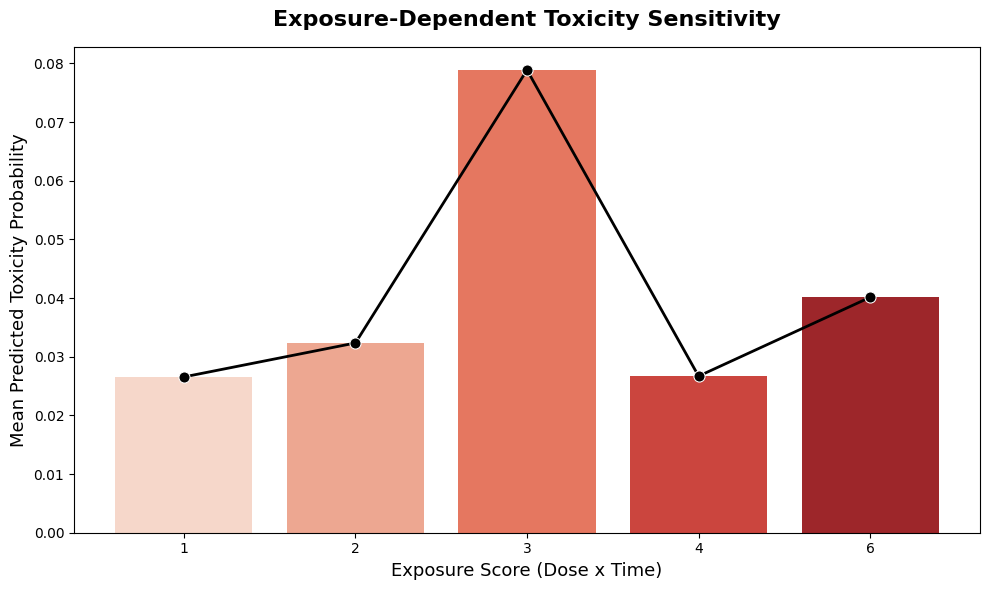

: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 준비
analysis_df = X_val.copy()
analysis_df['toxicity_proba'] = pred_matrix 
analysis_df['true_label'] = y_val

# 노출 지수(exposure_score) 별 평균 예측 확률 계산 후 데이터프레임으로 변환
grouped_data = analysis_df.groupby('exposure_score')['toxicity_proba'].mean().reset_index()

# 2. 시각화
plt.figure(figsize=(10, 6))

# 막대 그래프 (Bar plot) 그리기
ax = sns.barplot(
    x='exposure_score', 
    y='toxicity_proba', 
    data=grouped_data, 
    palette='Reds' 
)
x_coords = np.arange(len(grouped_data))
# 꺾은선(추세선) 추가
sns.lineplot(
    x=x_coords,
    y='toxicity_proba', 
    data=grouped_data, 
    color='black', 
    marker='o', 
    linewidth=2,
    markersize=8,
    ax=ax # 막대 그래프 위에 겹쳐 그림.
)

# 제목 및 라벨링
plt.title('Exposure-Dependent Toxicity Sensitivity', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Exposure Score (Dose x Time)', fontsize=13)
plt.ylabel('Mean Predicted Toxicity Probability', fontsize=13)

# 출력
plt.tight_layout()
plt.show()